# Develop an analysis workflow

### **Goal:** 

build an analysis workflow centered on database interactions

### **Requirements:**

* completion of all previous tutorials

### **Contents:**

* create a summary visualization of the dataset
* create a summary visualization of a session's spiking activity and movie contents
* correlate binned character appearances and spiking activity

In [ ]:
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from epiphyte.database.db_setup import *
from epiphyte.database.query_functions import *
from epiphyte.preprocessing.data_preprocessing.binning import *

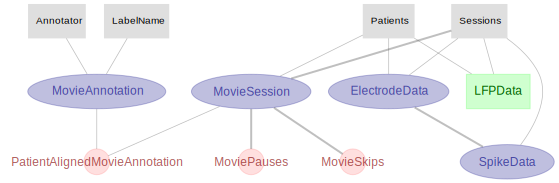

In [ ]:
erd = dj.ERD(epi_schema)
erd

### Create a summary visualization of all units in the database

- collect single- and multi-unit data from all sessions
- collect region-wise information for all units within each session
- visualize the watchlogs of each patient
- visualize the annotations on the base version of the movie (no specific pauses or skips factored in)

In [26]:
su_count = len(ElectrodeData & "unit_type='S'")
mu_count = len(ElectrodeData & "unit_type='M'")

region_df = pd.DataFrame(
{    "patient_id": ElectrodeData.fetch("patient_id"),
    "session_nr": ElectrodeData.fetch("session_nr"),
    "region": ElectrodeData.fetch("brain_region")}
)


counts = (
    region_df
    .groupby(["patient_id", "session_nr", "region"])
    .size()
    .reset_index(name="count")
)

counts["patient_session"] = (
    counts["patient_id"].astype(str) + "_s" + counts["session_nr"].astype(str)
)

pivot_df = counts.pivot(
    index="patient_session",
    columns="region",
    values="count"
).fillna(0)

annotations_df = pd.DataFrame(MovieAnnotation())

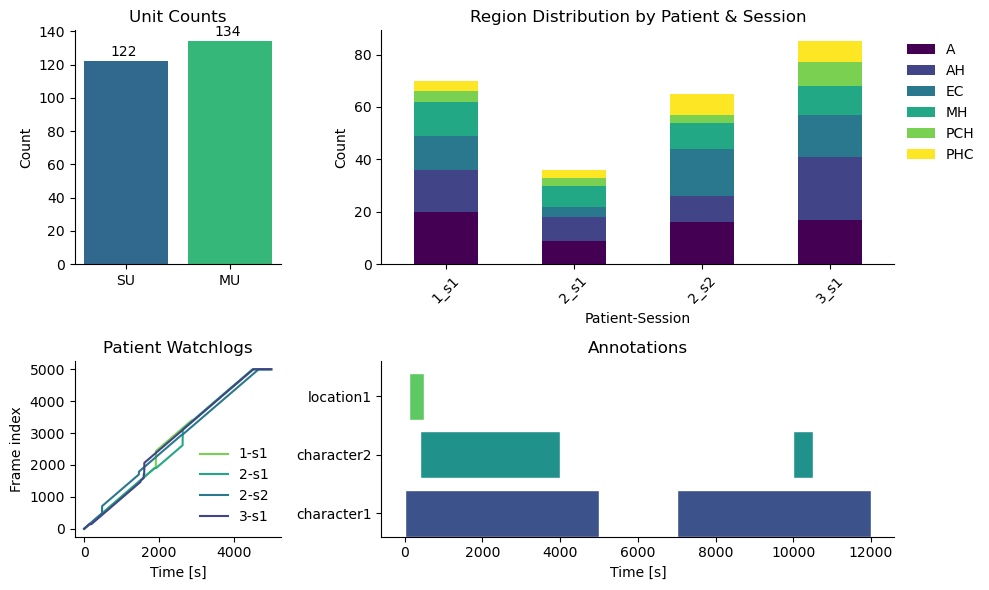

In [71]:
mosaic = """
    ABB
    CDD
    """

fig = plt.figure(figsize=(6,3),)
axes = fig.subplot_mosaic(
    mosaic,
    gridspec_kw={
        "height_ratios": [2, 1.5]  
    }
)

######
ax = axes["A"]
bar_colors = sns.color_palette("viridis",  n_colors=2)
ax.bar([0, 1], [su_count, mu_count], color=bar_colors)
ax.text(0-0.15, su_count+3, f"{su_count}")
ax.text(1-0.15, mu_count+3, f"{mu_count}")
ax.set_xticks([0,1])
ax.set_xticklabels(["SU", "MU"])
ax.set_ylabel("Count")
ax.set_title("Unit Counts")
sns.despine(ax=ax)

######
ax = axes["B"]
pivot_df.plot(
    ax=ax,
    kind="bar",
    stacked=True,
    figsize=(10,6),
    colormap="viridis"
)
ax.legend(frameon=False, bbox_transform=ax.transAxes, bbox_to_anchor = [1,1])
ax.set_title("Region Distribution by Patient & Session")
ax.set_xlabel("Patient-Session")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=45)
sns.despine(ax=ax)

######
ax = axes["C"]
pats, seshs = MovieSession.fetch("patient_id", "session_nr")
colors = sns.color_palette("viridis_r", n_colors=len(pats)) 
i = 0
for pat, sesh in zip(pats, seshs):
    
    pts, dts = (MovieSession & f"patient_id={pat}" & f"session_nr={sesh}").fetch("pts", "dts")
    pts = pts[0]
    dts = dts[0] - dts[0][0]
    dts = dts / 1000

    ax.plot(dts, pts, color=colors[i], label=f"{pat}-s{sesh}")
    i += 1

ax.set_title("Patient Watchlogs")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frame index")

sns.despine(ax=ax)
ax.legend(frameon=False)

######
ax = axes["D"]
yticks = []
ylabels = []
y_pos = 0

bar_colors = sns.color_palette("viridis",  n_colors=3)
bar_height = 0.8  

for idx, row in annotations_df.iterrows():
    starts = row['start_times']  
    stops = row['stop_times']
    values = row['values']
    color = bar_colors[idx]
    label = row['label_name']

    for start, stop, value in zip(starts, stops, values):
        if value:
            ax.axvspan(
                xmin=start,
                xmax=stop,
                ymin=y_pos / len(annotations_df),
                ymax=(y_pos + bar_height) / len(annotations_df),
                facecolor=color,
                alpha=1.0,
                edgecolor='white'
            )
    
    yticks.append(y_pos + bar_height / 2)
    ylabels.append(label)
    y_pos += 1 
ax.set_ylim(0, len(annotations_df))
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_xlabel("Time [s]")
ax.set_title("Annotations")
sns.despine(ax=ax)


plt.tight_layout()
plt.show()

### Visualize stimulus events and neuronal activity

- collect the patient-aligned labels (i.e. those with pauses and any skips in playback factored into the PTS vector)
- collect all spike times recorded from patient 1, session 1
- overlay the annotations on top of the spikes
- use preset query functions to simplify database calls

In [5]:
patient_id = 1
session_nr = 1

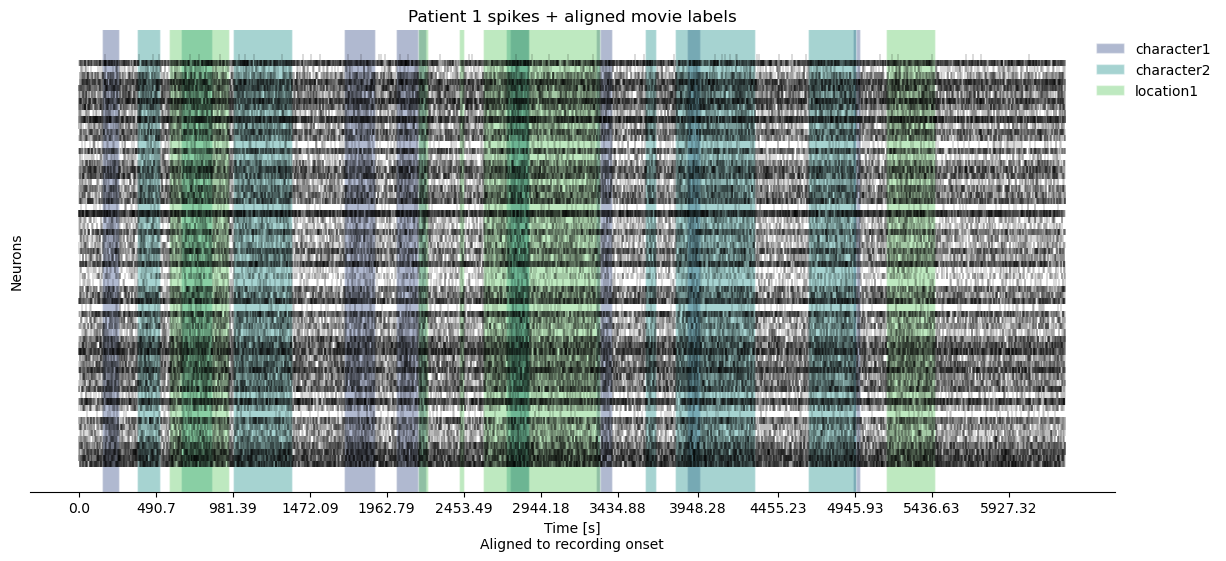

In [6]:
patient_spikes = (SpikeData & f"patient_id={patient_id}" & f"session_nr={session_nr}").fetch("spike_times")

rectime = get_patient_neural_rectime(patient_id, session_nr) 

fig, ax = plt.subplots(1,1,figsize=(14, 6))
ax.eventplot(patient_spikes, lw=0.2, color="black")

colors = sns.color_palette("viridis",  n_colors=3)

for i, label_name in enumerate(MovieAnnotation.fetch("label_name")):
    values, starts, stops = get_patient_aligned_label_info(patient_id, session_nr, label_name)
    c = 0
    for start, stop, value in zip(starts, stops, values):
        if c == 0:
            label_name = label_name
        else:
            label_name = None
        if value:
            ax.axvspan(
                xmin=start,
                xmax=stop,
                ymin=0,
                ymax=len(patient_spikes)-5,
                facecolor=colors[i],
                alpha=0.4,
                edgecolor='white',
                label=label_name
            )
            c += 1

ax.set_xticks(rectime[::10_000])
ax.set_xticklabels(((rectime[::10_000] - rectime[0]) / 1000).round(2))
ax.set_yticks([])

ax.set_xlabel("Time [s]\nAligned to recording onset")
ax.set_ylabel("Neurons")
ax.set_title("Patient 1 spikes + aligned movie labels")

ax.legend(frameon=False, bbox_transform=ax.transAxes, bbox_to_anchor = [1.1,1])

sns.despine(left=True)
plt.show()

### Calculate the correlation between character appearance and spiking activity

- collect label and spiking information
- bin label to 80 ms bins, excluding any pauses
- bin spikes to 80 ms bins, also excluding any pause
- correlate the resulting binned character presence and spiking activity

Note: spiking activity is totally random.

In [7]:
label_name = "character1"
values, starts, stops = get_patient_aligned_label_info(patient_id, session_nr, label_name)

spike_times = get_spike_times(patient_id, session_nr, 1)

bin_size = 80

label_binned = bin_label(
    patient_id=1,
    session_nr=1,
    values=values,
    start_times=starts,
    stop_times=stops,
    bin_size=bin_size,
    exclude_pauses=True,
)

spikes_binned = bin_spikes(
    patient_id=1,
    session_nr=1,
    spike_times=spike_times,
    bin_size=bin_size,
    exclude_pauses=True,
    output_edges=False,)

In [11]:
np.corrcoef(label_binned, spikes_binned)[0,1]

np.float64(-0.0015086612955703923)